In [7]:
import numpy as np
import itertools
import matplotlib.pyplot as plt

In [8]:

import sys
sys.path.append('/home/mark.bishop/Documents/Kea')

import kea
from kea.simulator import mff
from kea.statistics.statfunc import complete_symmetric_correlation_function


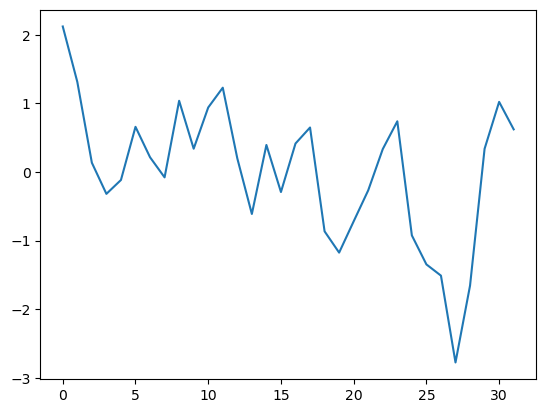

In [ ]:
D = 2
N = 32

kk = mff.make_grid(N, D)
field = mff.make_mff(kk[1], 2.*np.pi, 2./3., N)
plt.imshow(field)

In [10]:
ell, Q_full = complete_symmetric_correlation_function(field)

(np.int64(32),) (np.int64(17),)


NO MPI


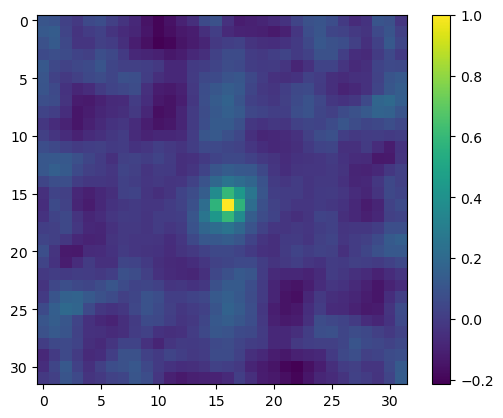

In [5]:
from kea.statistics.statfunc import mpi_acf

def make_acf(field, N, window=None):
    # Quadrant [0,0]
    l, acf = mpi_acf.mpi_acf(field, max_lag=N//2+1)
    Q = acf.reshape((N//2+1, N//2+1))

    # Quadrant [1,0]
    l_T, acf_T = mpi_acf.mpi_acf(field[::-1,:], max_lag=N//2+1)
    Q_T = acf_T.reshape((N//2+1, N//2+1))

    Q_full = np.zeros((N, N))

    # [0,0]
    # [mid -> end] = [cutoff end, ...]
    Q_full[N//2:,N//2:] = Q[:-1,:-1]
    # [1,1]
    Q_full[:N//2+1,:N//2+1] = Q[::-1,::-1]

    # [1,0]
    Q_full[:N//2+1,N//2:] = Q_T[:,:-1][::-1,:]
    # [0,1]
    Q_full[N//2:,:N//2+1] = Q_T[:-1,:][:,::-1]

    if window is not None:
        for i in range(N):
            Q_full[:,i] *= window
        for j in range(N):
            Q_full[j,:] *= window

    return Q_full#np.fft.ifftshift(Q_full)

Q_full2 = make_acf(field, N)
# Q_full2[N//2,N//2] = 0.
plt.imshow(Q_full2)
plt.colorbar()

-3.0531133177191805e-16 1.9984014443252818e-15


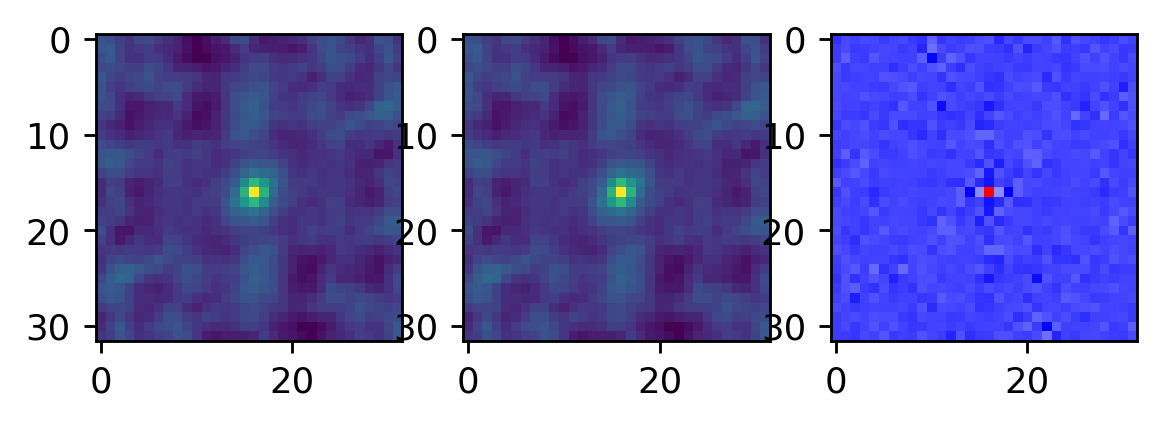

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(1.75*3., 1.75), dpi=256)

ax[0].imshow(Q_full, vmin=-0.2, vmax=1.)
ax[1].imshow(Q_full2, vmin=-0.2, vmax=1.)
ax[2].imshow(Q_full - Q_full2, cmap='bwr')
print(np.nanmin(Q_full - Q_full2), np.nanmax(Q_full - Q_full2))